In [1]:
import scarf

scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name="tenx_8K_pbmc_citeseq", save_path="scarf_datasets", as_zarr=True
)

Calculating summary statistics



Using cached feature stats for cell_key I



Using existing corrected dispersion values



Calculating HVGs



500 genes marked as HVGs



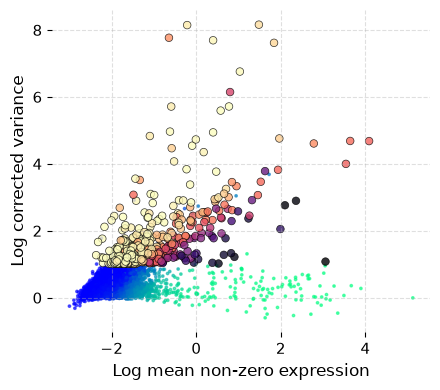

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.8s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.1s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.75%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 11.6s (7/7 steps, 11.5s in logged steps)



Saved marker results to RNA/markers/I__RNA_leiden_cluster in 0.4s (11 clusters, layout=compact_v2)



In [3]:
ds = scarf.DataStore("scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr", nthreads=4)

ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15)
ds.run_leiden_clustering(resolution=0.5)
ds.run_marker_search(group_key="RNA_leiden_cluster", gene_batch_size=100)

In [4]:
ds.show_zarr_tree(depth=1)

/
├── ADT
│   ├── counts (7865, 17) uint32
│   ├── featureData
│   └── normed__I__I
├── RNA
│   ├── counts (7865, 33538) uint32
│   ├── featureData
│   ├── markers
│   ├── normed__I__hvgs
│   └── summary_stats_I
└── cellData
    ├── ADT_UMAP1 (7865,) float32
    ├── ADT_UMAP2 (7865,) float32
    ├── ADT_leiden_cluster (7865,) int64
    ├── ADT_nCounts (7865,) float64
    ├── ADT_nFeatures (7865,) float64
    ├── I (7865,) bool
    ├── RNA_UMAP1 (7865,) float32
    ├── RNA_UMAP2 (7865,) float32
    ├── RNA_cluster (7865,) int64
    ├── RNA_leiden_cluster (7865,) int64
    ├── RNA_nCounts (7865,) float64
    ├── RNA_nFeatures (7865,) float64
    ├── RNA_percentMito (7865,) float64
    ├── RNA_percentRibo (7865,) float64
    ├── RNA_tSNE1 (7865,) float64
    ├── RNA_tSNE2 (7865,) float64
    ├── ids (7865,) <U18
    └── names (7865,) <U18



In [5]:
ds.show_zarr_tree(start="cellData")

/cellData
├── ADT_UMAP1 (7865,) float32
├── ADT_UMAP2 (7865,) float32
├── ADT_leiden_cluster (7865,) int64
├── ADT_nCounts (7865,) float64
├── ADT_nFeatures (7865,) float64
├── I (7865,) bool
├── RNA_UMAP1 (7865,) float32
├── RNA_UMAP2 (7865,) float32
├── RNA_cluster (7865,) int64
├── RNA_leiden_cluster (7865,) int64
├── RNA_nCounts (7865,) float64
├── RNA_nFeatures (7865,) float64
├── RNA_percentMito (7865,) float64
├── RNA_percentRibo (7865,) float64
├── RNA_tSNE1 (7865,) float64
├── RNA_tSNE2 (7865,) float64
├── ids (7865,) <U18
└── names (7865,) <U18

  RNA_percentMito: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_nFeatures: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_UMAP2: shape=(7865,), dtype=float32, chunks=(100000,)
  RNA_tSNE2: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_UMAP1: shape=(7865,), dtype=float32, chunks=(100000,)
  RNA_tSNE1: shape=(7865,), dtype=float64, chunks=(100000,)
  I: shape=(7865,), dtype=bool, chunks=(100000,)
  names: shape=(786

In [6]:
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── counts (7865, 33538) uint32
├── featureData
│   ├── I (33538,) bool
│   ├── I__hvgs (33538,) bool
│   ├── dropOuts (33538,) int64
│   ├── ids (33538,) <U15
│   ├── nCells (33538,) int64
│   └── names (33538,) <U16
├── markers
│   ├── I__RNA_cluster
│   └── I__RNA_leiden_cluster
├── normed__I__hvgs
│   ├── data (7549, 500) float32
│   ├── mu (500,) float64
│   ├── reduction__pca__15__I
│   └── sigma (500,) float64
└── summary_stats_I
    ├── avg (33538,) float64
    ├── c_var__200__0.1 (33538,) float64
    ├── normed_n (33538,) float64
    ├── normed_tot (33538,) float64
    ├── nz_mean (33538,) float64
    └── sigmas (33538,) float64

  counts: shape=(7865, 33538), dtype=uint32, chunks=(2000, 1000)


In [7]:
ds.show_zarr_tree(start="RNA/featureData", depth=1)

/RNA/featureData
├── I (33538,) bool
├── I__hvgs (33538,) bool
├── dropOuts (33538,) int64
├── ids (33538,) <U15
├── nCells (33538,) int64
└── names (33538,) <U16

  names: shape=(33538,), dtype=<U16, chunks=(100000,)
  I: shape=(33538,), dtype=bool, chunks=(100000,)
  nCells: shape=(33538,), dtype=int64, chunks=(100000,)
  I__hvgs: shape=(33538,), dtype=bool, chunks=(100000,)
  ids: shape=(33538,), dtype=<U15, chunks=(100000,)
  dropOuts: shape=(33538,), dtype=int64, chunks=(100000,)


In [8]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_tSNE2,ADT_nFeatures,ADT_UMAP2,RNA_tSNE1,ADT_UMAP1,RNA_percentRibo,ADT_nCounts,RNA_nFeatures,RNA_nCounts,RNA_cluster,RNA_UMAP2,ADT_leiden_cluster,RNA_leiden_cluster,RNA_UMAP1
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,8.668831,-18.08830,17.0,9.510007,-4.26865,-13.884989,15.259740,981.0,2194.0,6160.0,4,-7.417822,16,3,29.421942
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,6.316103,-14.88920,17.0,10.784672,5.02671,-5.097915,19.037688,1475.0,2093.0,6713.0,4,-12.649998,15,3,30.801842
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,8.056090,-18.83030,17.0,12.961405,-14.91320,-7.885502,16.002200,7149.0,1518.0,3637.0,5,4.256729,9,3,29.397541
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,9.003215,-3.35003,17.0,11.531997,16.69630,12.072053,18.729904,6831.0,737.0,1244.0,3,-32.227364,2,4,5.441914
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6.204519,-1.37607,17.0,12.290624,18.37000,13.928782,16.353887,6839.0,1240.0,2611.0,3,-30.397615,2,4,7.166490


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs,stats_I_normed_tot,stats_I_normed_n,stats_I_sigmas,stats_I_avg,stats_I_nz_mean,stats_I_c_var__200__0.1
0,False,ENSG00000243485,MIR1302-2HG,0,7865,False,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,7865,False,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,7865,False,NaN,NaN,NaN,NaN,NaN,NaN
3,False,ENSG00000238009,AL627309.1,12,7853,False,NaN,NaN,NaN,NaN,NaN,NaN
4,False,ENSG00000239945,AL627309.3,0,7865,False,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "RNA_leiden_cluster"]
).set_index("ids")

,RNA_nCounts,RNA_nFeatures,RNA_leiden_cluster
ids,,,
AAACCCAAGATTGTGA-1,6160.0,2194.0,3
AAACCCACATCGGTTA-1,6713.0,2093.0,3
AAACCCAGTACCGCGT-1,3637.0,1518.0,3
AAACCCAGTATCGAAA-1,1244.0,737.0,4
AAACCCAGTCGTCATA-1,2611.0,1240.0,4
...,...,...,...
TTTGTTGGTTCAAGTC-1,5830.0,2178.0,4
TTTGTTGGTTGCATGT-1,4096.0,1256.0,9
TTTGTTGGTTGCGGCT-1,5524.0,1907.0,3


In [11]:
cluster_labels = ds.cells.fetch("RNA_leiden_cluster")
cluster_labels.shape

(7549,)

In [12]:
cluster_labels_all = ds.cells.fetch_all("RNA_leiden_cluster")
cluster_labels_all.shape

(7865,)

In [13]:
is_cluster_1 = cluster_labels == 1
ds.cells.insert(column_name="is_cluster_1", values=is_cluster_1)

In [14]:
ds.cells.insert(column_name="is_cluster_1", values=is_cluster_1)

ValueError: ERROR: is_cluster_1 already exists. Please set `overwrite` to True to overwrite.

In [15]:
ds.cells.insert(column_name="is_cluster_1", values=is_cluster_1, overwrite=True)

In [16]:
ds.RNA.rawData

ChunkedArray(shape=(7865, 33538), dtype=uint32, chunksize=(2000, 33538), numblocks=4)

In [17]:
ds.RNA.normed()

ChunkedArray(shape=(7549, 13550), dtype=float64, chunksize=(2000, 13550), numblocks=4)

In [18]:
ds.RNA.normMethod

<function scarf.assay.norm_lib_size(assay: 'Assay', counts: scarf.chunked.ChunkedArray) -> scarf.chunked.ChunkedArray>

In [19]:
import inspect

print(inspect.getsource(ds.RNA.normMethod))

def norm_lib_size(assay: "Assay", counts: ChunkedArray) -> ChunkedArray:
    """Performs library size normalization on the data. This is the default
    method for RNA assays.

    Args:
        assay: An instance of the assay object
        counts: A chunked array with raw counts data

    Returns:  A chunked array (delayed matrix) containing normalized data.
    """
    assert assay.sf is not None and assay.scalar is not None
    return assay.sf * counts / assay.scalar.reshape(-1, 1)



In [20]:
def my_cool_normalization_method(assay, counts):
    import numpy as np

    # Calculate total counts for each cell
    lib_size = counts.sum(axis=1).reshape(-1, 1)

    # Library size normalization followed by log2 transformation
    return np.log2(counts / lib_size)


ds.RNA.normMethod = my_cool_normalization_method

In [21]:
ds.RNA.normMethod = scarf.assay.norm_dummy

In [22]:
ds.show_zarr_tree(start="RNA/normed__I__hvgs")

/RNA/normed__I__hvgs
├── data (7549, 500) float32
├── mu (500,) float64
├── reduction__pca__15__I
│   ├── ann__l2__50__50__48__4466
│   │   ├── ann_idx_bytes (3503016,) uint8
│   │   └── knn__11
│   ├── kmeans__1000__4466
│   │   ├── cluster_centers (1000, 15) float64
│   │   └── cluster_labels (7549,) float64
│   └── reduction (500, 15) float64
└── sigma (500,) float64

  sigma: shape=(500,), dtype=float64, chunks=(500,)
  data: shape=(7549, 500), dtype=float32, chunks=(7549, 500)
  mu: shape=(500,), dtype=float64, chunks=(500,)


In [23]:
ds.load_graph(
    from_assay="RNA", cell_key="I", feat_key="hvgs", symmetric=False, upper_only=False
)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 83039 stored elements and shape (7549, 7549)>

In [24]:
ds.show_zarr_tree(start="RNA/markers", depth=2)

/RNA/markers
├── I__RNA_cluster
│   ├── 1
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 10
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 11
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 12
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) 

In [25]:
ds.get_markers(
    group_key="RNA_leiden_cluster", group_id="1", min_score=0.1, min_frac_exp=0.1
)

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,NOG,0.53835,0.06256,0.00364,0.16809,0.01454,17.18982,1.158059e-144,11175
1,1,ANKRD55,0.51016,0.03739,0.00273,0.11619,0.01278,13.68610,1.173673e-87,3599
2,1,FHIT,0.50697,0.08223,0.01020,0.23238,0.04235,8.06411,9.395148e-130,2618
3,1,EPHX2,0.50259,0.07782,0.00877,0.22308,0.03484,8.87209,1.258879e-139,5926
4,1,CHRM3-AS2,0.46972,0.10064,0.01330,0.27343,0.04858,7.56614,1.034841e-157,1351
...,...,...,...,...,...,...,...,...,...,...
1557,1,PDS5A,0.10007,0.04411,0.04662,0.14020,0.18600,0.94611,2.157832e-03,3167
1558,1,TCEA1,0.10007,0.13215,0.13002,0.34857,0.41467,1.01637,8.382182e-02,6005
1559,1,IER3IP1,0.10002,0.06307,0.06707,0.19830,0.25775,0.94034,1.866355e-03,11567
1560,1,DLD,0.10002,0.03881,0.03774,0.12781,0.16075,1.02823,2.663180e-02,5198


In [26]:
ds.export_markers_to_csv(
    group_key="RNA_leiden_cluster",
    csv_filename="test.csv",
    min_score=0.2,
    min_frac_exp=0.1,
)